# NDVI Change and Recovery After the 2017 Eagle Creek Fire (2014–2024)

The Eagle Creek Fire (2017) burned a large portion of the Columbia River Gorge in northern Oregon, affecting forest structure, recreation access, and viewsheds along the Interstate 84 corridor and the Historic Columbia River Highway. In this project, I use satellite-derived NDVI (Normalized Difference Vegetation Index) to quantify how vegetation greenness changed inside the fire perimeter and how it has recovered relative to nearby unburned areas.

**Research Question**

How did NDVI change inside the Eagle Creek Fire scar compared to surrounding unburned forests, and what does the NDVI trajectory suggest about vegetation recovery in the years following the fire?

**Objectives**

1. Delineate the Eagle Creek Fire burn area using an MTBS (Monitoring Trends in Burn Severity) fire-perimeter polygon.
2. Derive annual NDVI metrics for a multiyear period before and after the fire (e.g., 2014–2024).
3. Compare NDVI trends inside the burn area to a nearby unburned “control” region.
4. Visualize both:
   - A time series of NDVI inside vs. outside the burn.
   - A sequence of NDVI maps illustrating pre-fire conditions, immediate post-fire decline, and subsequent recovery.

## Background and Context

The Eagle Creek Fire started in early September 2017 in the Columbia River Gorge, eventually burning thousands of acres of mixed conifer and broadleaf forest. The Gorge is a high-visibility landscape that supports hiking, tourism, and transportation, so changes in vegetation cover are both ecologically and socially important.

NDVI (Normalized Difference Vegetation Index) is a widely used remote-sensing metric that approximates vegetation vigor and canopy density. NDVI is defined as:

\[
\text{NDVI} = \frac{NIR - Red}{NIR + Red}
\]

where *NIR* is reflectance in a near-infrared band and *Red* is reflectance in a red band. Higher NDVI values generally indicate more photosynthetically active vegetation.

Post-fire recovery studies often use NDVI (or related indices) to:

- Quantify immediate loss of canopy cover after fire.
- Track regrowth of shrubs, grasses, and trees over time.
- Compare burn severity classes or burned vs. unburned reference areas.

In this project, I focus on NDVI-based comparison of burned vs. unburned areas across multiple years, rather than detailed burn-severity classes, to keep the analysis reasonable.

In [1]:
import os

import numpy as np
import pandas as pd
import geopandas as gpd
import xarray as xr
import rioxarray as rxr  
from shapely.geometry import Polygon

### maps and plots
import holoviews as hv
import hvplot.pandas
import hvplot.xarray

### open street map
from osmnx import features as osm
import osmnx as ox

### file structure
import os
from pathlib import Path

### earthpy
import earthpy
import earthpy.api.appeears as eaapp

import matplotlib.pyplot as plt

# Plot settings
plt.rcParams["figure.figsize"] = (8, 6)
plt.rcParams["axes.grid"] = False

xr.set_options(display_style="text")

from collections import defaultdict

In [2]:
for shp in Path("/workspaces").rglob("*.shp"):
    print(shp)

/workspaces/data/or4563012190420170902_20160812_20180818_burn_bndy.shp
/workspaces/data/gilariverdata/tl_2020_us_aitsn/tl_2020_us_aitsn.shp


In [3]:
### set up project and folder for data
project = earthpy.Project("EagleCreek", dirname = 'eagle_creek_ndvi')

fire_perimeter_path = Path("/workspaces/data/or4563012190420170902_20160812_20180818_burn_bndy.shp")
fire_gdf = gpd.read_file(fire_perimeter_path)

fire_gdf.head(), fire_gdf.crs

(                Event_ID                               irwinID   Incid_Name  \
 0  OR4563012190420170902  B942230F-938F-4584-93A0-D406F53284C6  EAGLE CREEK   
 1  OR4563012190420170902  B942230F-938F-4584-93A0-D406F53284C6  EAGLE CREEK   
 
   Incid_Type    Map_ID Map_Prog Asmnt_Type  BurnBndAc BurnBndLat BurnBndLon  \
 0   Wildfire  10008499     MTBS   Extended         44     45.595   -122.064   
 1   Wildfire  10008499     MTBS   Extended      48773     45.618   -121.942   
 
    ... Perim_ID dNBR_offst dNBR_stdDv NoData_T  IncGreen_T  Low_T  Mod_T  \
 0  ...     None        -17         21     -970        -150     25    275   
 1  ...     None        -17         21     -970        -150     25    275   
 
    High_T  Comment                                           geometry  
 0     630     None  POLYGON ((-2009207.8 2789104.158, -2009180.813...  
 1     630     None  POLYGON ((-1984423.871 2792882.713, -1984351.1...  
 
 [2 rows x 23 columns],
 <Projected CRS: ESRI:102039>
 Name: U

<Axes: >

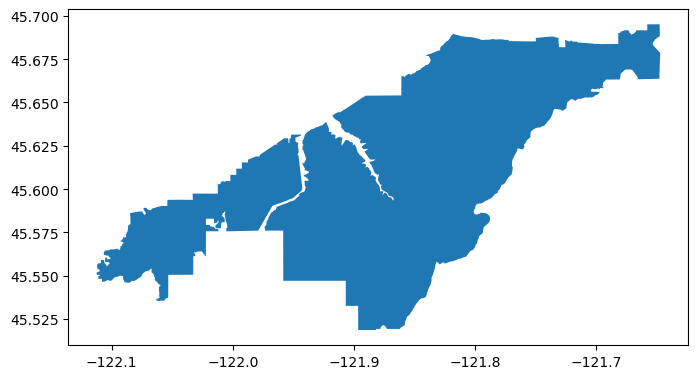

In [4]:
### Get Polygon for area of interest
hatfield_gdf = ox.geocode_to_gdf(
    'Mark O. Hatfield Wilderness')

### make a quick plot
hatfield_gdf.plot()

In [5]:
# Years to analyze
pre_fire_years = list(range(2014, 2017))   # 2014, 2015, 2016
fire_year = 2017                           # fire start year
post_fire_years = list(range(2018, 2025))  # 2018–2024

all_years = pre_fire_years + [fire_year] + post_fire_years

all_years

[2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]

In [6]:
### initialize AppeearsDownloader for MODIS NDVI data
download_key = "eagle-creek-ndvi"

# ensure polygon is in geographic (lat/lon) before passing to AppEEARS
gdf = hatfield_gdf.to_crs("EPSG:4326")

### set parameters
ndvi_downloader = eaapp.AppeearsDownloader(

    download_key = download_key,

    ### specify the MODIS product you want
    product = 'MOD13Q1.061',
    layer = '_250m_16_days_NDVI',

    ### choose a start date and end data
    start_date = "08-01",
    end_date = "08-31",

    ### recurring means you want those dates over multiple years
    recurring = True,

    ### specify the range of years you want
    year_range = [2014, 2024],

    ### specify the polygon you want to get NDVI data for
    polygon = gdf
)

In [ ]:
### download the prepared download -- this can take a while!
ndvi_downloader.download_files(cache=True)

In [7]:
### get a sorted list of NDVI file paths
project.project_dir = Path("/workspaces/data/earthpy-downloads/eagle-creek-ndvi")
ndvi_paths = sorted(list(project.project_dir.rglob('*NDVI*.tif')))

ndvi_paths

[PosixPath('/workspaces/data/earthpy-downloads/eagle-creek-ndvi/MOD13Q1.061_2014198_to_2024244/MOD13Q1.061__250m_16_days_NDVI_doy2014209000000_aid0001.tif'),
 PosixPath('/workspaces/data/earthpy-downloads/eagle-creek-ndvi/MOD13Q1.061_2014198_to_2024244/MOD13Q1.061__250m_16_days_NDVI_doy2014225000000_aid0001.tif'),
 PosixPath('/workspaces/data/earthpy-downloads/eagle-creek-ndvi/MOD13Q1.061_2014198_to_2024244/MOD13Q1.061__250m_16_days_NDVI_doy2014241000000_aid0001.tif'),
 PosixPath('/workspaces/data/earthpy-downloads/eagle-creek-ndvi/MOD13Q1.061_2014198_to_2024244/MOD13Q1.061__250m_16_days_NDVI_doy2015209000000_aid0001.tif'),
 PosixPath('/workspaces/data/earthpy-downloads/eagle-creek-ndvi/MOD13Q1.061_2014198_to_2024244/MOD13Q1.061__250m_16_days_NDVI_doy2015225000000_aid0001.tif'),
 PosixPath('/workspaces/data/earthpy-downloads/eagle-creek-ndvi/MOD13Q1.061_2014198_to_2024244/MOD13Q1.061__250m_16_days_NDVI_doy2015241000000_aid0001.tif'),
 PosixPath('/workspaces/data/earthpy-downloads/eagle

In [8]:
# Group all the MODIS NDVI files by year using the "doyYYYY" part of the filename
paths_by_year = defaultdict(list)

for p in ndvi_paths:
    name = p.name
    # Extract the part after "doy", then the next 4 characters for the year
    year_str = name.split("doy")[1][:4]
    year = int(year_str)
    paths_by_year[year].append(p)

# Quick sanity check: how many scenes per year?
for yr in sorted(paths_by_year):
    print(yr, "->", len(paths_by_year[yr]), "files")

2014 -> 3 files
2015 -> 3 files
2016 -> 3 files
2017 -> 3 files
2018 -> 2 files
2019 -> 3 files
2020 -> 3 files
2021 -> 3 files
2022 -> 2 files
2023 -> 3 files
2024 -> 2 files


In [9]:
#Build inside-fire and outside-ring polygons
# Use a projected CRS for buffering in meters
projected_crs = "EPSG:5070"   

# Reproject the fire perimeter
fire_proj = fire_gdf.to_crs(projected_crs)

# Dissolve to a single polygon (in case there are multiple pieces)
burn_geom = fire_proj.unary_union

# Make a ring around the fire: buffer outward, then subtract inside
buffer_distance = 3000  # 3 km ring
outer_buffer = burn_geom.buffer(buffer_distance)
outside_ring_geom = outer_buffer.difference(burn_geom)

# Turn those geometries back into GeoDataFrames
inside_gdf_proj = gpd.GeoDataFrame(
    {"region": ["inside_burn"], "geometry": [burn_geom]},
    crs=projected_crs,
)

outside_gdf_proj = gpd.GeoDataFrame(
    {"region": ["outside_burn"], "geometry": [outside_ring_geom]},
    crs=projected_crs,
)

/tmp/ipykernel_1082/1776760401.py:9: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  burn_geom = fire_proj.unary_union


In [10]:
# Checking for scaling
test = rxr.open_rasterio(ndvi_paths[0]).squeeze("band", drop=True)

print("Min:", float(test.min().values))
print("Max:", float(test.max().values))

Min: -1506.0
Max: 9254.0


In [11]:
# Build a composite NDVI for each year
def load_ndvi_for_year(year: int) -> xr.DataArray:
    """
    Load a composite NDVI for a given year by combining all MOD13Q1
    NDVI scenes for that year in `paths_by_year`.

    Composite rule: pixelwise max NDVI across available dates (late July–August).
    """
    if year not in paths_by_year:
        raise ValueError(f"No NDVI files found for year {year}")

    das = []
    for path in sorted(paths_by_year[year]):
        da = rxr.open_rasterio(path).squeeze("band", drop=True)
        das.append(da)

    if len(das) == 1:
        ndvi_da = das[0]
    else:
        stack = xr.concat(das, dim="time")
        ndvi_da = stack.max(dim="time")  # or .mean(dim="time") if you prefer

    ndvi_da = ndvi_da.astype("float32")

    ndvi_da = ndvi_da / 10000.0

    return ndvi_da

In [12]:
# Compute mean NDVI inside vs outside for each year
def summarize_ndvi_for_year(year: int):
    """
    For a given year:
      - load the NDVI composite
      - clip to inside and outside fire regions
      - return mean NDVI in each region
    """
    ndvi_da = load_ndvi_for_year(year)

    if ndvi_da.rio.crs is None:
        raise ValueError("NDVI raster has no CRS; please check your file.")

    # Reproject polygons to match NDVI CRS
    inside_for_clip = inside_gdf_proj.to_crs(ndvi_da.rio.crs)
    outside_for_clip = outside_gdf_proj.to_crs(ndvi_da.rio.crs)

    # Clip NDVI to each region
    ndvi_inside = ndvi_da.rio.clip(
        inside_for_clip.geometry,
        inside_for_clip.crs,
        drop=True,
        all_touched=True
    )

    ndvi_outside = ndvi_da.rio.clip(
        outside_for_clip.geometry,
        outside_for_clip.crs,
        drop=True,
        all_touched=True
    )

    # Flatten and drop NaNs
    inside_vals = ndvi_inside.values.ravel()
    outside_vals = ndvi_outside.values.ravel()

    inside_vals = inside_vals[~np.isnan(inside_vals)]
    outside_vals = outside_vals[~np.isnan(outside_vals)]

    return {
        "year": year,
        "ndvi_inside_mean": float(inside_vals.mean()) if inside_vals.size > 0 else np.nan,
        "ndvi_outside_mean": float(outside_vals.mean()) if outside_vals.size > 0 else np.nan,
    }

In [13]:
# Loop over all years
results = []

for yr in sorted(paths_by_year.keys()):
    print(f"Summarizing NDVI for year {yr}...")
    res = summarize_ndvi_for_year(yr)
    results.append(res)

ndvi_summary = pd.DataFrame(results).set_index("year").sort_index()
ndvi_summary

Summarizing NDVI for year 2014...
Summarizing NDVI for year 2015...
Summarizing NDVI for year 2016...
Summarizing NDVI for year 2017...
Summarizing NDVI for year 2018...
Summarizing NDVI for year 2019...
Summarizing NDVI for year 2020...
Summarizing NDVI for year 2021...
Summarizing NDVI for year 2022...
Summarizing NDVI for year 2023...
Summarizing NDVI for year 2024...


,ndvi_inside_mean,ndvi_outside_mean
year,,
2014,0.882055,0.805465
2015,0.869107,0.791324
2016,0.861081,0.787937
2017,0.859030,0.793848
2018,0.592020,0.763774
2019,0.663089,0.789433
2020,0.698367,0.785831
2021,0.690883,0.801479
2022,0.723663,0.774548


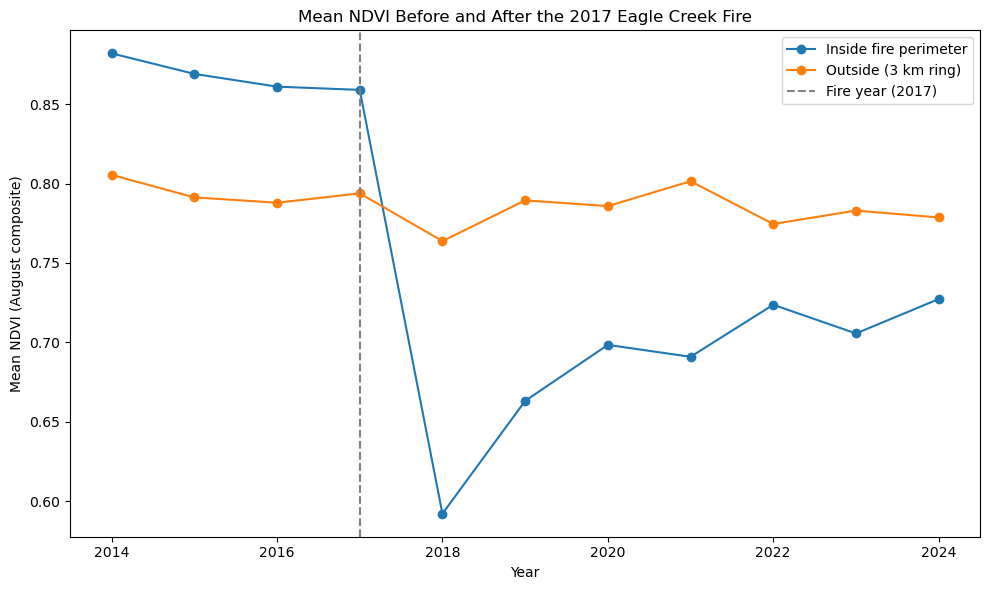

In [14]:
# Plot NDVI before and after the fire
fire_year = 2017  # Eagle Creek Fire year

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    ndvi_summary.index,
    ndvi_summary["ndvi_inside_mean"],
    marker="o",
    label="Inside fire perimeter",
)
ax.plot(
    ndvi_summary.index,
    ndvi_summary["ndvi_outside_mean"],
    marker="o",
    label="Outside (3 km ring)",
)

# Mark the fire year with a vertical line
ax.axvline(fire_year, linestyle="--", linewidth=1.5, color="gray", label="Fire year (2017)")

ax.set_xlabel("Year")
ax.set_ylabel("Mean NDVI (August composite)")
ax.set_title("Mean NDVI Before and After the 2017 Eagle Creek Fire")
ax.legend()
plt.tight_layout()
plt.show()

2016 NDVI: EPSG:4326 (86, 224)
2018 NDVI: EPSG:4326 (86, 224)
Clipped 2016 NDVI: (86, 224)
Clipped 2018 NDVI: (86, 224)
NDVI diff stats: min = -0.7125999927520752 max = 0.06540000438690186


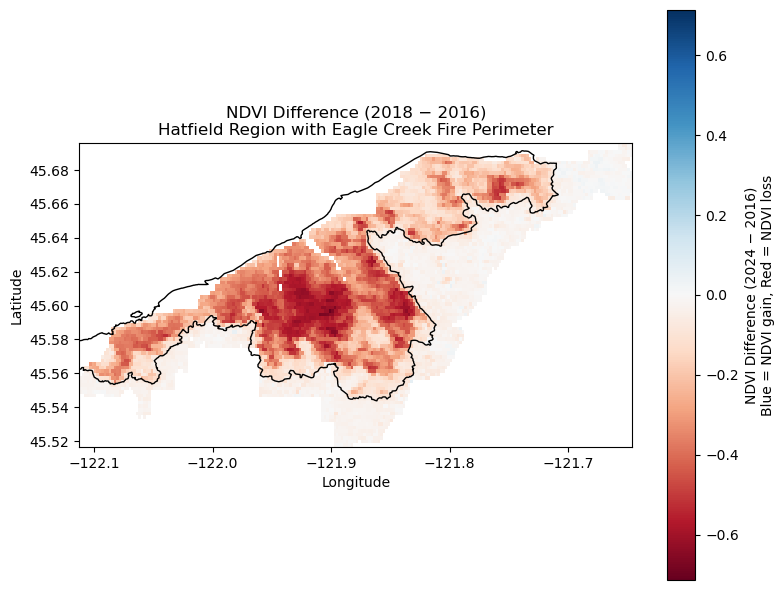

In [15]:
# NDVI Difference image 2018 - 2016 over the Hatfield polygon
# Load yearly NDVI composites
ndvi_2016 = load_ndvi_for_year(2016)
ndvi_2018 = load_ndvi_for_year(2018)

print("2016 NDVI:", ndvi_2016.rio.crs, ndvi_2016.shape)
print("2018 NDVI:", ndvi_2018.rio.crs, ndvi_2018.shape)

# Reproject 2018 NDVI to exactly match 2016 grid if needed
if (ndvi_2018.rio.crs != ndvi_2016.rio.crs) or (
    ndvi_2018.rio.resolution() != ndvi_2016.rio.resolution()
):
    ndvi_2018 = ndvi_2018.rio.reproject_match(ndvi_2016)

# Reproject Hatfield to NDVI CRS
hatfield_ndvi = hatfield_gdf.to_crs(ndvi_2016.rio.crs)

# Clip NDVI to Hatfield AOI
ndvi_2016_hat = ndvi_2016.rio.clip(
    hatfield_ndvi.geometry,
    hatfield_ndvi.crs,
    drop=True,
    all_touched=True
)

ndvi_2018_hat = ndvi_2018.rio.clip(
    hatfield_ndvi.geometry,
    hatfield_ndvi.crs,
    drop=True,
    all_touched=True
)

print("Clipped 2016 NDVI:", ndvi_2016_hat.shape)
print("Clipped 2018 NDVI:", ndvi_2018_hat.shape)  

# Difference: positive = greener in 2018, negative = loss of greenness
ndvi_diff = ndvi_2018_hat - ndvi_2016_hat

print(
    "NDVI diff stats:",
    "min =", float(np.nanmin(ndvi_diff.values)),
    "max =", float(np.nanmax(ndvi_diff.values))
)

# Symmetric color limits around 0 so gains/losses are visually balanced
max_abs = float(np.nanmax(np.abs(ndvi_diff.values)))
vlim = max_abs if max_abs > 0 else 0.5  # fallback if weird

fig, ax = plt.subplots(figsize=(8, 6))

im = ndvi_diff.plot(
    ax=ax,
    cmap="RdBu",      # blue = loss, red = gain 
    vmin=-vlim,
    vmax=vlim,
    add_colorbar=True
)

# Overlay fire perimeter
fire_ndvi = fire_gdf.to_crs(ndvi_2016.rio.crs)
fire_ndvi.boundary.plot(ax=ax, edgecolor="black", linewidth=1)

ax.set_title("NDVI Difference (2018 − 2016)\nHatfield Region with Eagle Creek Fire Perimeter")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

# Colorbar label
cbar = im.colorbar
cbar.set_label("NDVI Difference (2024 − 2016)\nBlue = NDVI gain, Red = NDVI loss")

plt.tight_layout()
plt.show()

NDVI diff (2024–2016): min = -0.42739999294281006 max = 0.15999996662139893


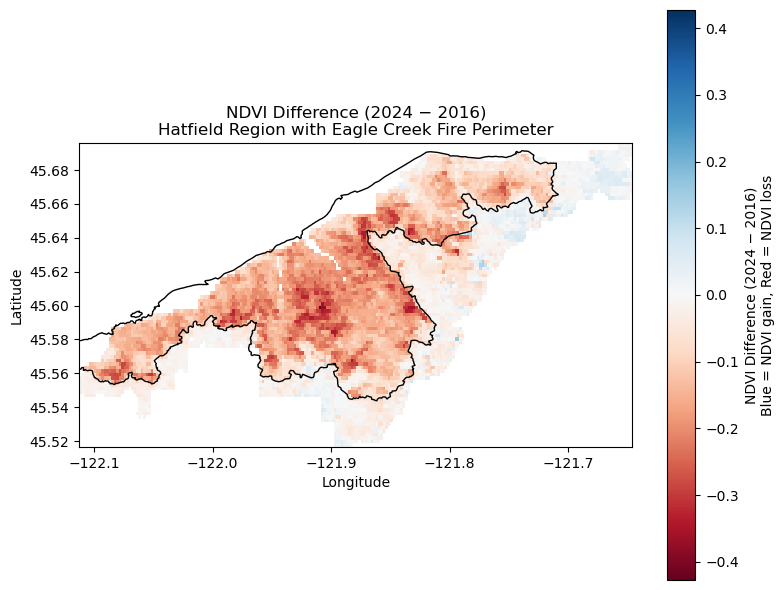

In [16]:
# 2024 - 2016  How much has the area recovered (seven years later)

# 1. Load composites
ndvi_2016 = load_ndvi_for_year(2016)
ndvi_2024 = load_ndvi_for_year(2024)

# 2. Ensure same grid
if (ndvi_2024.rio.crs != ndvi_2016.rio.crs) or (
    ndvi_2024.rio.resolution() != ndvi_2016.rio.resolution()
):
    ndvi_2024 = ndvi_2024.rio.reproject_match(ndvi_2016)

# 3. Clip both to Hatfield AOI
hatfield_ndvi = hatfield_gdf.to_crs(ndvi_2016.rio.crs)

ndvi_2016_hat = ndvi_2016.rio.clip(
    hatfield_ndvi.geometry, hatfield_ndvi.crs,
    drop=True, all_touched=True
)
ndvi_2024_hat = ndvi_2024.rio.clip(
    hatfield_ndvi.geometry, hatfield_ndvi.crs,
    drop=True, all_touched=True
)

# 4. Difference = 2024 – 2016
ndvi_diff_24_16 = ndvi_2024_hat - ndvi_2016_hat

print(
    "NDVI diff (2024–2016):",
    "min =", float(np.nanmin(ndvi_diff_24_16.values)),
    "max =", float(np.nanmax(ndvi_diff_24_16.values))
)

# 5. Plot using ORIGINAL orientation: RdBu (blue = negative, red = positive)
max_abs = float(np.nanmax(np.abs(ndvi_diff_24_16.values)))
vlim = max_abs if max_abs > 0 else 0.5

fig, ax = plt.subplots(figsize=(8, 6))

im = ndvi_diff_24_16.plot(
    ax=ax,
    cmap="RdBu",     # <<-- same as your first map
    vmin=-vlim,
    vmax=vlim,
    add_colorbar=True
)

# Fire perimeter
fire_ndvi = fire_gdf.to_crs(ndvi_2016.rio.crs)
fire_ndvi.boundary.plot(ax=ax, edgecolor="black", linewidth=1)

ax.set_title("NDVI Difference (2024 − 2016)\nHatfield Region with Eagle Creek Fire Perimeter")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

# Colorbar label
cbar = im.colorbar
cbar.set_label("NDVI Difference (2024 − 2016)\nBlue = NDVI gain, Red = NDVI loss")

plt.tight_layout()
plt.show()

NDVI diff (2024–2018): min = -0.30049997568130493 max = 0.4327000379562378


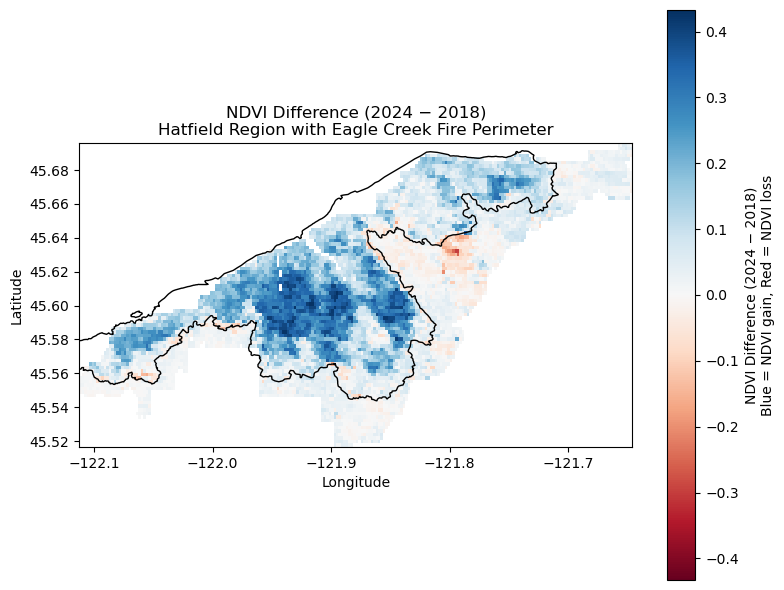

In [17]:
# 2024 - 2018  How much has the area recovered since the fire.

# 1. Load composites
ndvi_2018 = load_ndvi_for_year(2018)
ndvi_2024 = load_ndvi_for_year(2024)

# 2. Ensure same grid
if (ndvi_2024.rio.crs != ndvi_2018.rio.crs) or (
    ndvi_2024.rio.resolution() != ndvi_2018.rio.resolution()
):
    ndvi_2024 = ndvi_2024.rio.reproject_match(ndvi_2018)

# 3. Clip both to Hatfield AOI
hatfield_ndvi = hatfield_gdf.to_crs(ndvi_2018.rio.crs)

ndvi_2018_hat = ndvi_2018.rio.clip(
    hatfield_ndvi.geometry, hatfield_ndvi.crs,
    drop=True, all_touched=True
)
ndvi_2024_hat = ndvi_2024.rio.clip(
    hatfield_ndvi.geometry, hatfield_ndvi.crs,
    drop=True, all_touched=True
)

# 4. Difference = 2024 – 2018
ndvi_diff_24_18 = ndvi_2024_hat - ndvi_2018_hat

print(
    "NDVI diff (2024–2018):",
    "min =", float(np.nanmin(ndvi_diff_24_18.values)),
    "max =", float(np.nanmax(ndvi_diff_24_18.values))
)

# 5. Plot using ORIGINAL orientation: RdBu (blue = negative, red = positive)
max_abs = float(np.nanmax(np.abs(ndvi_diff_24_18.values)))
vlim = max_abs if max_abs > 0 else 0.5

fig, ax = plt.subplots(figsize=(8, 6))

im = ndvi_diff_24_18.plot(
    ax=ax,
    cmap="RdBu",     
    vmin=-vlim,
    vmax=vlim,
    add_colorbar=True
)

# Fire perimeter
fire_ndvi = fire_gdf.to_crs(ndvi_2018.rio.crs)
fire_ndvi.boundary.plot(ax=ax, edgecolor="black", linewidth=1)

ax.set_title("NDVI Difference (2024 − 2018)\nHatfield Region with Eagle Creek Fire Perimeter")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

# Colorbar label
cbar = im.colorbar
cbar.set_label("NDVI Difference (2024 − 2018)\nBlue = NDVI gain, Red = NDVI loss")

plt.tight_layout()
plt.show()

2016: (86, 224) EPSG:4326
2018: (86, 224) EPSG:4326
2024: (86, 224) EPSG:4326
Clipped shapes: (71, 194) (71, 194) (71, 194)
Recovery stats (ignoring NaN):
  min: -2.1800005
  5th, 50th, 95th percentiles: [-0.10560452  0.51275975  0.79308757]


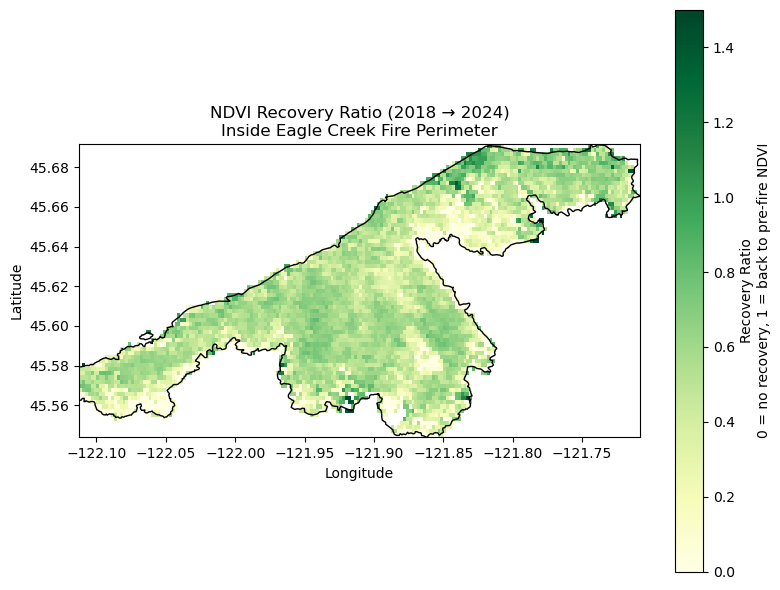

In [19]:
# Recovery Trajectory Map Inside the Fire Perimeter

# 1. Load NDVI composites for key years
ndvi_2016 = load_ndvi_for_year(2016)
ndvi_2018 = load_ndvi_for_year(2018)
ndvi_2024 = load_ndvi_for_year(2024)

# 2. Make sure they share the same grid / CRS
# (AppEEARS usually ensures this, but let's be safe)
if (ndvi_2018.rio.crs != ndvi_2016.rio.crs) or (
    ndvi_2018.rio.resolution() != ndvi_2016.rio.resolution()
):
    ndvi_2018 = ndvi_2018.rio.reproject_match(ndvi_2016)

if (ndvi_2024.rio.crs != ndvi_2016.rio.crs) or (
    ndvi_2024.rio.resolution() != ndvi_2016.rio.resolution()
):
    ndvi_2024 = ndvi_2024.rio.reproject_match(ndvi_2016)

print("2016:", ndvi_2016.shape, ndvi_2016.rio.crs)
print("2018:", ndvi_2018.shape, ndvi_2018.rio.crs)
print("2024:", ndvi_2024.shape, ndvi_2024.rio.crs)

# 3. Clip all three rasters to the *fire perimeter* only
fire_ndvi = fire_gdf.to_crs(ndvi_2016.rio.crs)

ndvi_2016_fire = ndvi_2016.rio.clip(
    fire_ndvi.geometry, fire_ndvi.crs,
    drop=True, all_touched=True
)
ndvi_2018_fire = ndvi_2018.rio.clip(
    fire_ndvi.geometry, fire_ndvi.crs,
    drop=True, all_touched=True
)
ndvi_2024_fire = ndvi_2024.rio.clip(
    fire_ndvi.geometry, fire_ndvi.crs,
    drop=True, all_touched=True
)

print("Clipped shapes:", ndvi_2016_fire.shape, ndvi_2018_fire.shape, ndvi_2024_fire.shape)

# 4. Compute pre- and post-fire changes relative to 2018
# (we expect 2016 > 2018 inside the burn)
pre_loss = ndvi_2016_fire - ndvi_2018_fire     # how much NDVI was lost
post_gain = ndvi_2024_fire - ndvi_2018_fire    # how much NDVI has come back

# 5. Build recovery ratio:
#    0   -> no recovery
#    1   -> fully back to pre-fire NDVI
#   >1   -> above pre-fire NDVI
#
# Guard against divide-by-zero or tiny pre-loss values (unburned / unchanged pixels)
pre_loss_vals = pre_loss.values
post_gain_vals = post_gain.values

recovery = np.full_like(pre_loss_vals, np.nan, dtype="float32")

# Define a minimum NDVI loss to consider "burned"
loss_threshold = 0.05  # NDVI units

valid_mask = np.abs(pre_loss_vals) > loss_threshold

recovery[valid_mask] = post_gain_vals[valid_mask] / pre_loss_vals[valid_mask]

# Wrap back into a DataArray with spatial metadata
recovery_da = ndvi_2016_fire.copy(data=recovery)
recovery_da.name = "ndvi_recovery_ratio"

print("Recovery stats (ignoring NaN):")
print("  min:", np.nanmin(recovery))
print("  5th, 50th, 95th percentiles:",
      np.nanpercentile(recovery, [5, 50, 95]))

# 6. For plotting, clip extreme values to a reasonable range
#    (e.g., 0 to 1.5, where 1.0 = full recovery)
recovery_plot = recovery_da.clip(0, 1.5)

fig, ax = plt.subplots(figsize=(8, 6))

im = recovery_plot.plot(
    ax=ax,
    cmap="YlGn",          # sequential: pale = low recovery, dark = strong recovery
    vmin=0,
    vmax=1.5,
    add_colorbar=True
)

# Overlay fire perimeter outline
fire_ndvi.boundary.plot(ax=ax, edgecolor="black", linewidth=1)

ax.set_title("NDVI Recovery Ratio (2018 → 2024)\nInside Eagle Creek Fire Perimeter")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

cbar = im.colorbar
cbar.set_label("Recovery Ratio\n0 = no recovery, 1 = back to pre-fire NDVI")

plt.tight_layout()
plt.show()